In [101]:
import pandas as pd
import os
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [102]:
BASE_DIR = os.path.dirname(os.getcwd())

df = pd.read_csv(os.path.join(BASE_DIR,'data','processed','cleaned_europe_sales.csv'))

df.head(5)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,2010-01-01,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,2010-02-01,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88
2,Europe,Austria,Cereal,Offline,C,2014-08-13,2010-03-01,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44
3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,2010-04-01,672330081,2010-11-29,6266,651.21,524.96,4080481.86,3289399.36,791082.50
4,Europe,Estonia,Fruits,Online,L,2016-09-28,2010-05-01,579463422,2016-11-01,4958,9.33,6.92,46258.14,34309.36,11948.78


In [103]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df = df.set_index('Order Date').sort_index()

In [104]:
kosovo = df.loc[df['Country'] == 'Kosovo'][['Total Revenue','Total Profit']]
kosovo

,Total Revenue,Total Profit
Order Date,,
2010-01-13,677247.76,277519.48
2010-05-02,63332.04,16359.08
2010-09-26,680720.40,270715.59
2011-02-01,3207629.67,434891.60
2011-05-07,4151463.75,804843.75
2011-06-03,4100498.80,1630726.73
2011-07-13,619627.38,223923.54
2011-08-27,39363.27,10167.79
2011-11-09,22792.35,4418.75


In [105]:
kosovo_sales = kosovo['Total Revenue'].resample('ME').sum()
kosovo_sales

Order Date
2010-01-31     677247.76
2010-02-28          0.00
2010-03-31          0.00
2010-04-30          0.00
2010-05-31      63332.04
                 ...    
2017-03-31    1527813.02
2017-04-30          0.00
2017-05-31          0.00
2017-06-30          0.00
2017-07-31    1750207.78
Freq: ME, Name: Total Revenue, Length: 91, dtype: float64

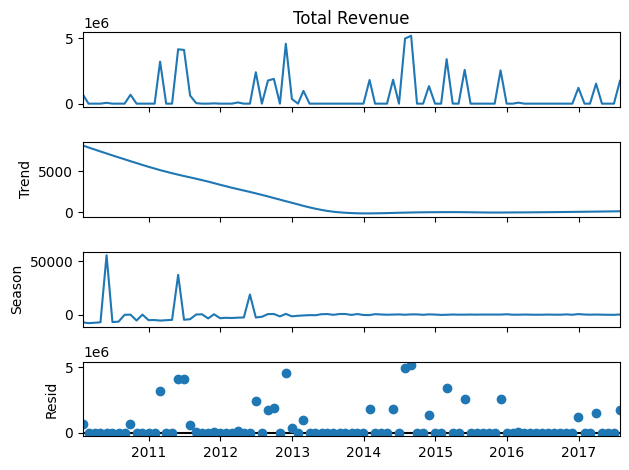

In [106]:
kosovo_decompo = STL(kosovo_sales,period=12,robust=True).fit()

kosovo_decompo.plot()
plt.show()

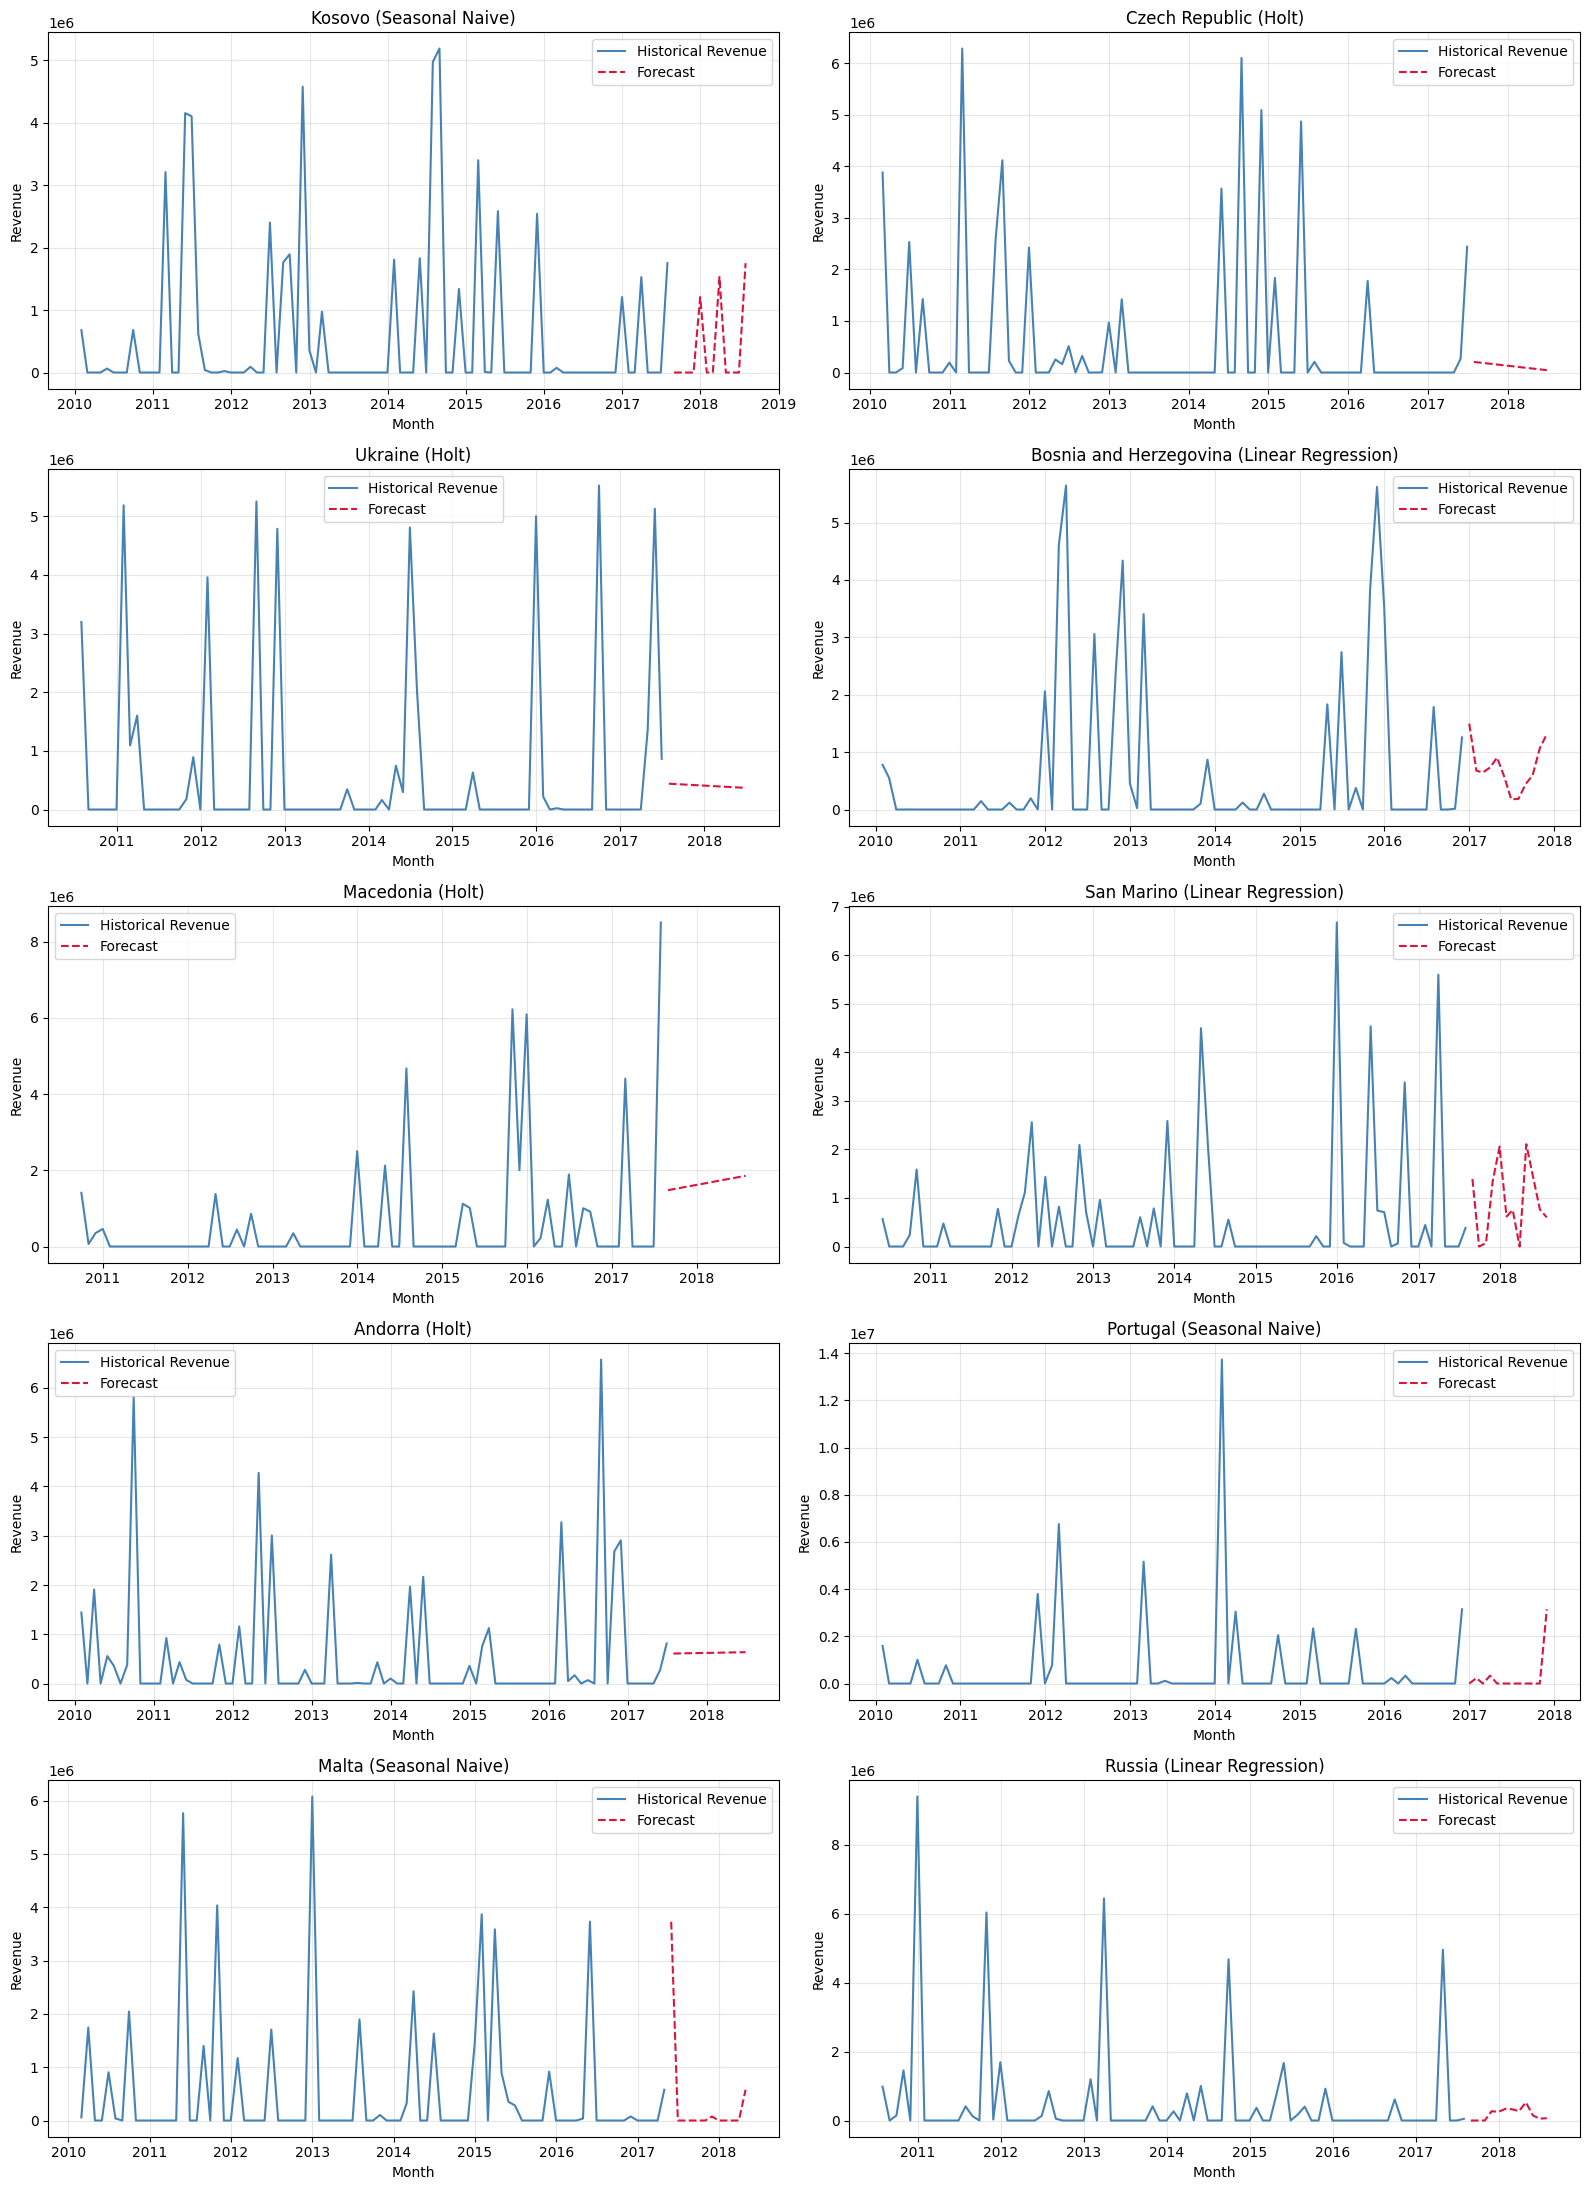

,Country,Best Model,Holdout MAE,Holdout RMSE,Next 12 Months Forecast
0,Macedonia,Holt,1652584.17,2491290.59,19998548.25
1,San Marino,Linear Regression,943046.17,1519493.11,11122169.92
2,Bosnia and Herzegovina,Linear Regression,1372949.41,1696626.69,8811609.97
3,Andorra,Holt,1171149.72,2081559.78,7469853.79
4,Ukraine,Holt,1134117.80,2170372.72,4855321.69
5,Kosovo,Seasonal Naive,591689.21,1053246.34,4484984.64
6,Malta,Seasonal Naive,420001.61,1020296.52,4384532.31
7,Portugal,Seasonal Naive,697062.69,1319706.21,3709836.11
8,Russia,Linear Regression,576456.58,1443683.03,2261028.60
9,Czech Republic,Holt,376550.32,696792.32,1507036.80


C:\Users\Soy\AppData\Local\Temp\ipykernel_8292\4042905359.py:187: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  top_10_country_forecasts.round(2)


,Country,Forecast Month,Forecast Revenue
0,Kosovo,2017-08-31,0.00
1,Kosovo,2017-09-30,0.00
2,Kosovo,2017-10-31,0.00
3,Kosovo,2017-11-30,0.00
4,Kosovo,2017-12-31,1206963.84
...,...,...,...
115,Russia,2018-03-31,273719.46
116,Russia,2018-04-30,529163.33
117,Russia,2018-05-31,145746.56
118,Russia,2018-06-30,53527.04


In [107]:
forecast_steps = 12
top_n_countries = 10

def build_time_features(series):
    feature_df = pd.DataFrame({'y': series.copy()})
    feature_df['time_idx'] = np.arange(len(feature_df))
    feature_df['month'] = feature_df.index.month
    feature_df['quarter'] = feature_df.index.quarter
    feature_df['month_sin'] = np.sin(2 * np.pi * feature_df['month'] / 12)
    feature_df['month_cos'] = np.cos(2 * np.pi * feature_df['month'] / 12)
    feature_df['lag_1'] = feature_df['y'].shift(1)
    feature_df['lag_2'] = feature_df['y'].shift(2)
    feature_df['lag_3'] = feature_df['y'].shift(3)
    feature_df['lag_6'] = feature_df['y'].shift(6)
    feature_df['lag_12'] = feature_df['y'].shift(12)
    feature_df['rolling_mean_3'] = feature_df['y'].shift(1).rolling(3).mean()
    feature_df['rolling_mean_6'] = feature_df['y'].shift(1).rolling(6).mean()
    return feature_df

def recursive_linear_forecast(history, steps):
    history = history.copy()
    feature_df = build_time_features(history).dropna()
    feature_cols = [col for col in feature_df.columns if col != 'y']
    model = LinearRegression()
    model.fit(feature_df[feature_cols], feature_df['y'])

    predictions = []
    for _ in range(steps):
        next_date = history.index[-1] + pd.offsets.MonthEnd(1)
        next_row = pd.DataFrame(index=[next_date])
        next_row['time_idx'] = len(history)
        next_row['month'] = next_date.month
        next_row['quarter'] = next_date.quarter
        next_row['month_sin'] = np.sin(2 * np.pi * next_date.month / 12)
        next_row['month_cos'] = np.cos(2 * np.pi * next_date.month / 12)
        next_row['lag_1'] = history.iloc[-1]
        next_row['lag_2'] = history.iloc[-2]
        next_row['lag_3'] = history.iloc[-3]
        next_row['lag_6'] = history.iloc[-6]
        next_row['lag_12'] = history.iloc[-12]
        next_row['rolling_mean_3'] = history.iloc[-3:].mean()
        next_row['rolling_mean_6'] = history.iloc[-6:].mean()

        pred = model.predict(next_row[feature_cols])[0]
        pred = max(pred, 0)
        predictions.append(pred)
        history.loc[next_date] = pred

    forecast_index = pd.date_range(
        start=history.index[-steps],
        periods=steps,
        freq='ME'
    )
    return pd.Series(predictions, index=forecast_index)

def seasonal_naive_forecast(history, steps, seasonal_period=12):
    values = []
    for i in range(steps):
        values.append(history.iloc[-seasonal_period + i])
    forecast_index = pd.date_range(
        start=history.index[-1] + pd.offsets.MonthEnd(1),
        periods=steps,
        freq='ME'
    )
    return pd.Series(values, index=forecast_index)

def evaluate_models(series, steps=12):
    train = series.iloc[:-steps]
    test = series.iloc[-steps:]

    holt_fit = ExponentialSmoothing(
        train,
        trend='add',
        seasonal=None,
        initialization_method='estimated'
    ).fit(optimized=True)
    holt_pred = pd.Series(holt_fit.forecast(steps), index=test.index)
    snaive_pred = seasonal_naive_forecast(train, steps)
    linear_pred = recursive_linear_forecast(train, steps)

    scores = pd.DataFrame({
        'Model': ['Holt', 'Seasonal Naive', 'Linear Regression'],
        'MAE': [
            mean_absolute_error(test, holt_pred),
            mean_absolute_error(test, snaive_pred),
            mean_absolute_error(test, linear_pred)
        ],
        'RMSE': [
            np.sqrt(mean_squared_error(test, holt_pred)),
            np.sqrt(mean_squared_error(test, snaive_pred)),
            np.sqrt(mean_squared_error(test, linear_pred))
        ]
    }).sort_values('MAE').reset_index(drop=True)
    return scores

def fit_best_forecast(series, steps=12):
    scores = evaluate_models(series, steps=steps)
    best_model_name = scores.loc[0, 'Model']

    if best_model_name == 'Holt':
        fitted_model = ExponentialSmoothing(
            series,
            trend='add',
            seasonal=None,
            initialization_method='estimated'
        ).fit(optimized=True)
        forecast = pd.Series(fitted_model.forecast(steps))
        forecast.index = pd.date_range(
            start=series.index[-1] + pd.offsets.MonthEnd(1),
            periods=steps,
            freq='ME'
        )
    elif best_model_name == 'Seasonal Naive':
        forecast = seasonal_naive_forecast(series, steps)
    else:
        forecast = recursive_linear_forecast(series, steps)

    return best_model_name, scores, forecast

top_countries = (
    df.groupby('Country')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(top_n_countries)
    .index
)

monthly_country_sales = (
    df[df['Country'].isin(top_countries)]
    .groupby('Country')['Total Revenue']
    .resample('ME')
    .sum()
    .reset_index()
)

forecast_summary = []
forecast_tables = []

fig, axes = plt.subplots(5, 2, figsize=(16, 22), sharex=False)
axes = axes.flatten()

for ax, country in zip(axes, top_countries):
    country_series = (
        monthly_country_sales.loc[monthly_country_sales['Country'] == country, ['Order Date', 'Total Revenue']]
        .set_index('Order Date')
        .sort_index()['Total Revenue']
        .asfreq('ME', fill_value=0)
    )

    best_model_name, scores, forecast = fit_best_forecast(country_series, steps=forecast_steps)
    forecast_total = forecast.sum()

    forecast_summary.append({
        'Country': country,
        'Best Model': best_model_name,
        'Holdout MAE': scores.loc[0, 'MAE'],
        'Holdout RMSE': scores.loc[0, 'RMSE'],
        'Next 12 Months Forecast': forecast_total
    })

    country_forecast_df = pd.DataFrame({
        'Country': country,
        'Forecast Month': forecast.index,
        'Forecast Revenue': forecast.values
    })
    forecast_tables.append(country_forecast_df)

    ax.plot(country_series.index, country_series.values, label='Historical Revenue', color='steelblue')
    ax.plot(forecast.index, forecast.values, label='Forecast', color='crimson', linestyle='--')
    ax.set_title(f'{country} ({best_model_name})')
    ax.set_xlabel('Month')
    ax.set_ylabel('Revenue')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

forecast_summary_df = pd.DataFrame(forecast_summary).sort_values(
    by='Next 12 Months Forecast',
    ascending=False
).reset_index(drop=True)

top_10_country_forecasts = pd.concat(forecast_tables, ignore_index=True)

display(forecast_summary_df.round(2))
top_10_country_forecasts.round(2)

Top 10 Countries:
Index(['Kosovo', 'Czech Republic', 'Ukraine', 'Bosnia and Herzegovina',
       'Macedonia', 'San Marino', 'Andorra', 'Portugal', 'Malta', 'Russia'],
      dtype='str', name='Country')


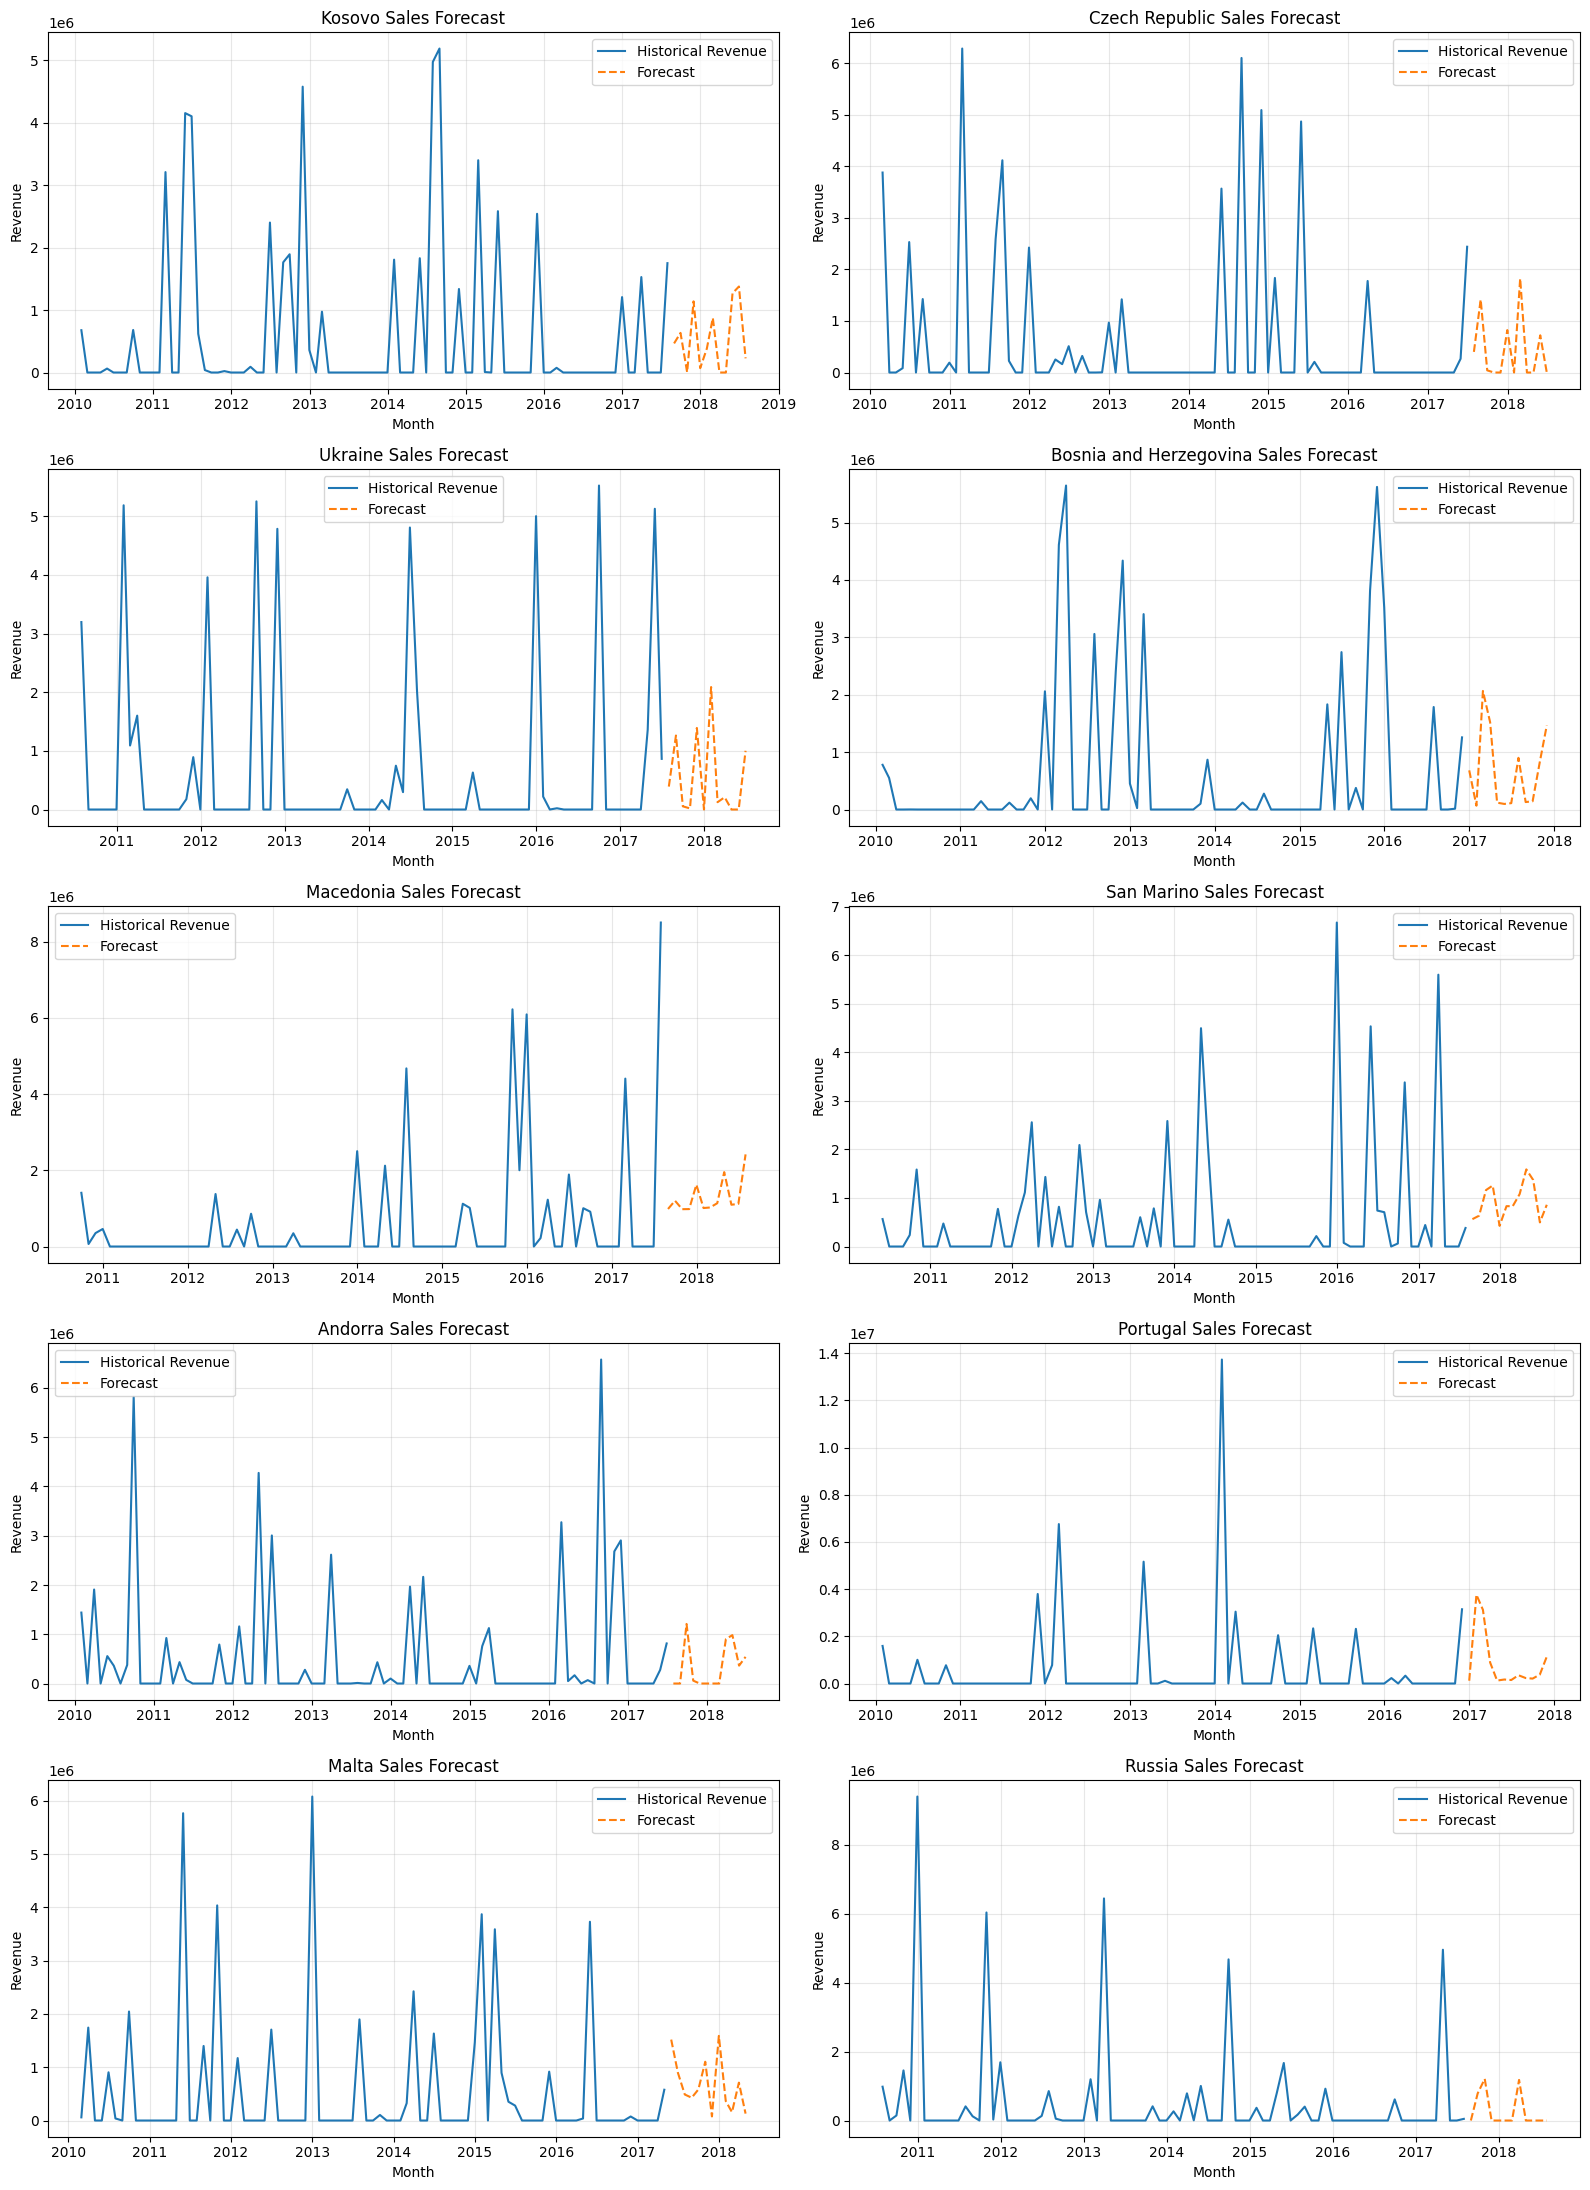


Forecast Summary:
  Country       Date  Forecast Revenue
0  Kosovo 2017-08-31      4.656860e+05
1  Kosovo 2017-09-30      6.341205e+05
2  Kosovo 2017-10-31      4.853840e+03
3  Kosovo 2017-11-30      1.138907e+06
4  Kosovo 2017-12-31      6.975145e+04


In [108]:
# 2. GET TOP 10 COUNTRIES
# ==============================
top_countries = (
    df.groupby('Country')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

print("Top 10 Countries:")
print(top_countries)

# ==============================
# 3. CREATE SUBPLOTS
# ==============================
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

# ==============================
# 4. LOOP THROUGH COUNTRIES
# ==============================
forecast_results = []

for ax, country in zip(axes, top_countries):

    # Create monthly time series
    country_series = (
        df[df['Country'] == country]['Total Revenue']
        .resample('ME')
        .sum()
    )

    # Fit model
    model = ExponentialSmoothing(
        country_series,
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )

    fit = model.fit()

    # Forecast next 12 months
    forecast = fit.forecast(12)

    # Optional: remove negative values
    forecast = forecast.clip(lower=0)

    # Save results
    forecast_results.append(pd.DataFrame({
        'Country': country,
        'Date': forecast.index,
        'Forecast Revenue': forecast.values
    }))

    # ==============================
    # 5. PLOT (FIXED VERSION)
    # ==============================
    ax.plot(country_series.index, country_series.values, label='Historical Revenue')
    ax.plot(forecast.index, forecast.values, label='Forecast', linestyle='--')

    ax.set_title(f'{country} Sales Forecast')
    ax.set_xlabel('Month')
    ax.set_ylabel('Revenue')
    ax.grid(alpha=0.3)
    ax.legend()

# ==============================
# 6. FINAL DISPLAY
# ==============================
plt.tight_layout()
plt.show()

# ==============================
# 7. COMBINE ALL FORECASTS
# ==============================
final_forecast_df = pd.concat(forecast_results)

print("\nForecast Summary:")
print(final_forecast_df.head())

In [109]:
final_forecast_df

,Country,Date,Forecast Revenue
0,Kosovo,2017-08-31,4.656860e+05
1,Kosovo,2017-09-30,6.341205e+05
2,Kosovo,2017-10-31,4.853840e+03
3,Kosovo,2017-11-30,1.138907e+06
4,Kosovo,2017-12-31,6.975145e+04
...,...,...,...
7,Russia,2018-03-31,1.177684e+06
8,Russia,2018-04-30,0.000000e+00
9,Russia,2018-05-31,0.000000e+00
10,Russia,2018-06-30,0.000000e+00


In [110]:
selected_columns = [
    'Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
    'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
    'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'
]

table_df = df[selected_columns].copy()

# Heatmaps work best with numeric columns, so we use the measurable sales fields here.
numeric_columns = [
    'Units Sold', 'Unit Price', 'Unit Cost',
    'Total Revenue', 'Total Cost', 'Total Profit'
]

correlation_matrix = table_df[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Heatmap of Sales Table Numeric Columns')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KeyError: "['Order Date'] not in index"

In [ ]:
# Select numerical columns
num_cols = ['Units Sold', 'Unit Price', 'Unit Cost', 
            'Total Revenue', 'Total Cost', 'Total Profit']

corr = df[num_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap')
plt.show()

KeyError: "None of [Index(['Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost',\n       'Total Profit'],\n      dtype='str')] are in the [columns]"

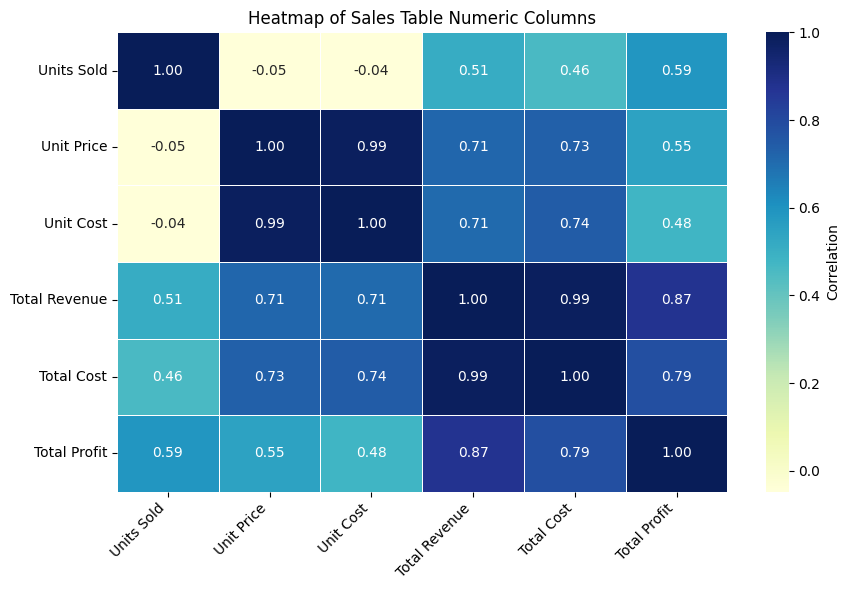

In [ ]:
sales_df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'cleaned_europe_sales.csv'))
sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'], errors='coerce')

selected_columns = [
    'Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
    'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
    'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'
]

table_df = sales_df[selected_columns].copy()

numeric_columns = [
    'Units Sold', 'Unit Price', 'Unit Cost',
    'Total Revenue', 'Total Cost', 'Total Profit'
]

correlation_matrix = table_df[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Heatmap of Europe Table Numeric Columns')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


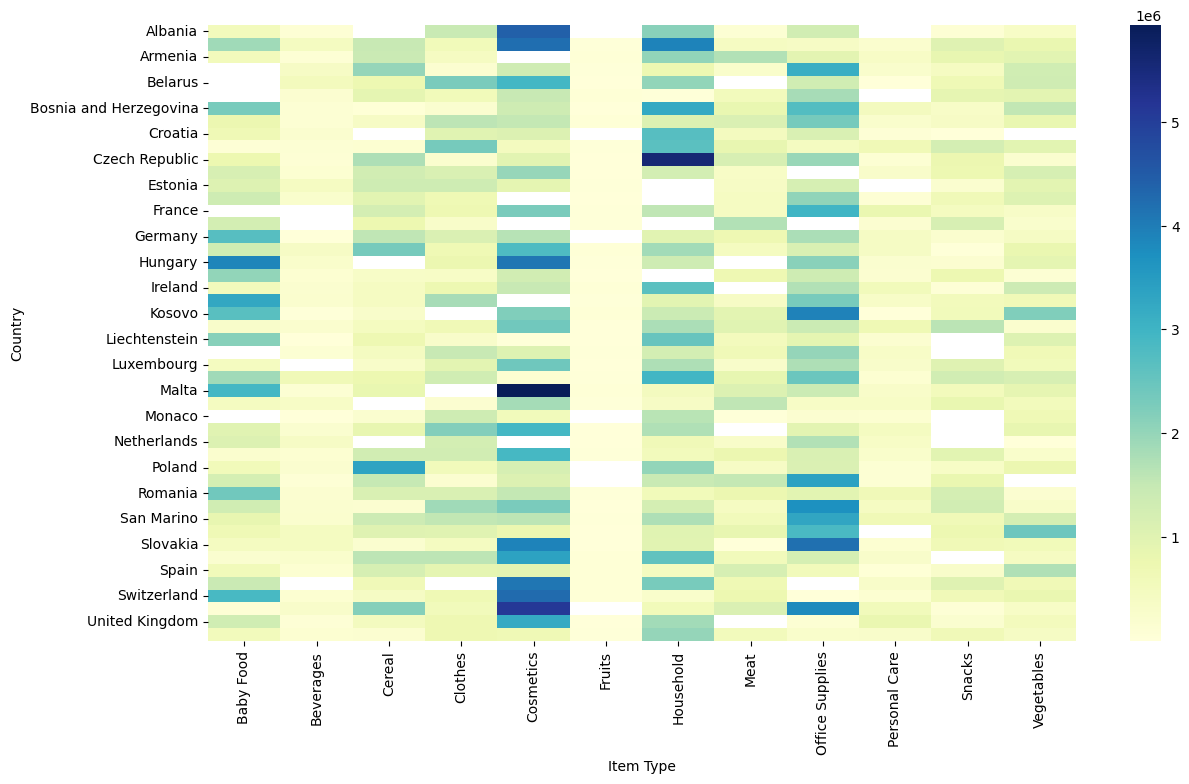

In [112]:
pivot = df.pivot_table(
    index='Country',
    columns='Item Type',
    values='Total Profit',
    aggfunc='sum'
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.show()


In [ ]:
df

,Region,Country,Item Type,Sales Channel,Order Priority,Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
Order Date,,,,,,,,,,,,,,
2010-01-01,Europe,Hungary,Baby Food,Offline,C,2013-12-01,279703605,2010-01-10,9367,255.28,159.42,2391207.76,1493287.14,897920.62
2010-01-01,Europe,Liechtenstein,Cereal,Online,L,2010-09-11,940682303,2010-02-09,7652,205.70,117.11,1574016.40,896125.72,677890.68
2010-01-03,Europe,Armenia,Clothes,Online,L,2013-01-23,231450879,2010-02-22,313,109.28,35.84,34204.64,11217.92,22986.72
2010-01-06,Europe,Belarus,Cosmetics,Offline,M,2011-11-21,521874034,2010-02-03,2979,437.20,263.33,1302418.80,784460.07,517958.73
2010-01-10,Europe,Italy,Clothes,Online,H,2013-06-18,689421546,2010-01-31,4011,109.28,35.84,438322.08,143754.24,294567.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-07-17,Europe,Macedonia,Beverages,Offline,M,2011-06-11,704139363,2017-08-31,9340,47.45,31.79,443183.00,296918.60,146264.40
2017-07-18,Europe,Kosovo,Cereal,Offline,H,2011-06-30,483655774,2017-08-05,3346,205.70,117.11,688272.20,391850.06,296422.14
2017-07-20,Europe,Switzerland,Cosmetics,Online,C,2010-02-18,233811223,2017-07-20,8792,437.20,263.33,3843862.40,2315197.36,1528665.04
